In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

import pickle


In [2]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv("water_potability.csv")

# Show first rows
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (3276, 10)

Columns:
Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

Data Types:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


In [4]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [5]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


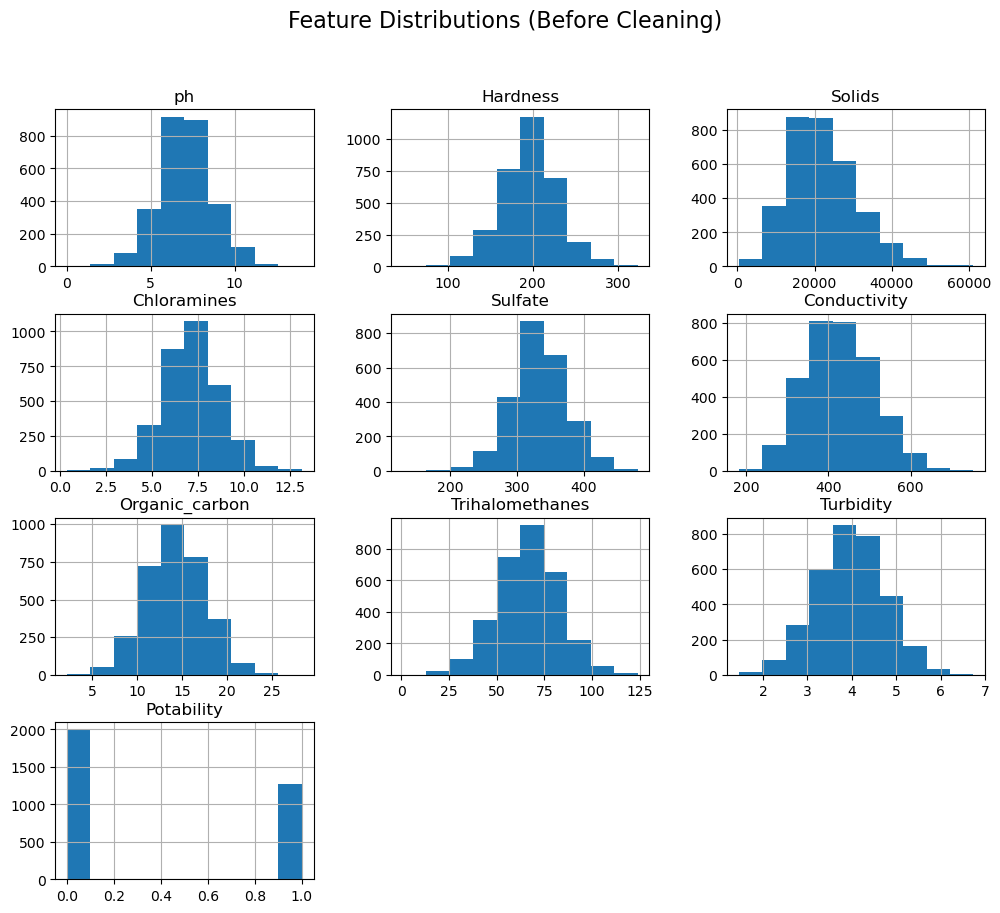

In [6]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions (Before Cleaning)", fontsize=16)
plt.show()

In [9]:
cols = df.select_dtypes(include=np.number).columns.drop("Potability")
cols

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity'],
      dtype='object')

In [10]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

ph: 46 outliers
Hardness: 83 outliers
Solids: 47 outliers
Chloramines: 61 outliers
Sulfate: 41 outliers
Conductivity: 11 outliers
Organic_carbon: 25 outliers
Trihalomethanes: 33 outliers
Turbidity: 19 outliers


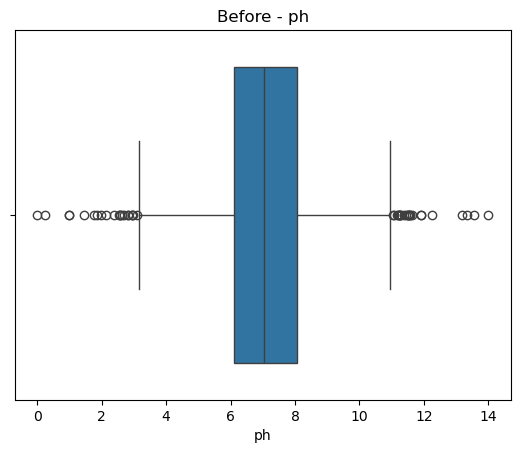

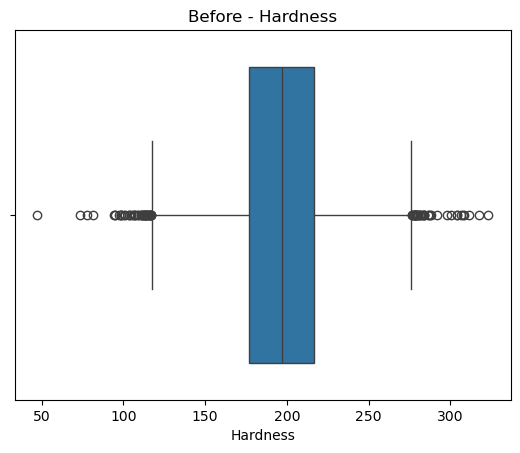

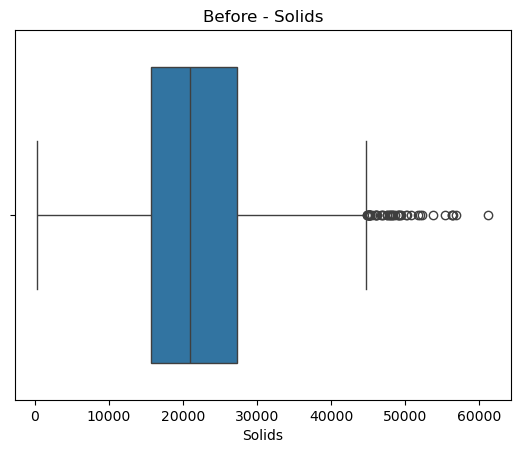

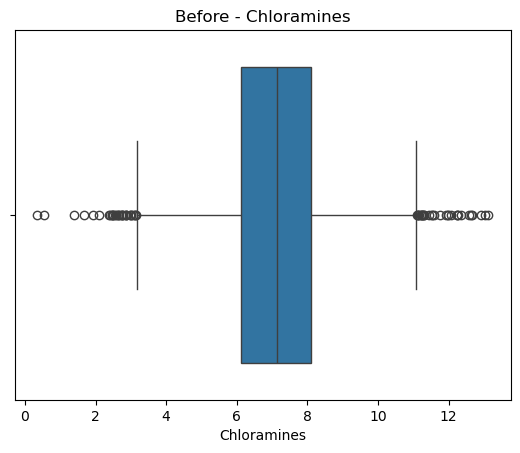

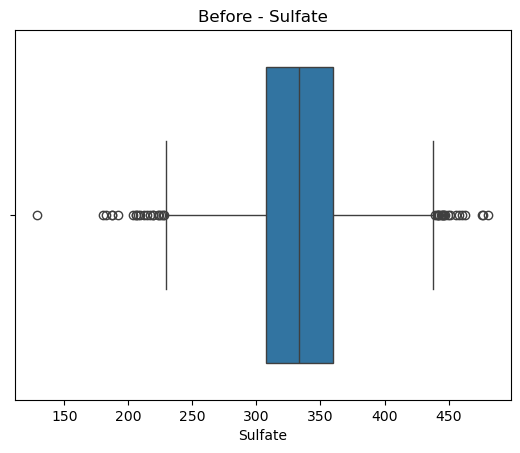

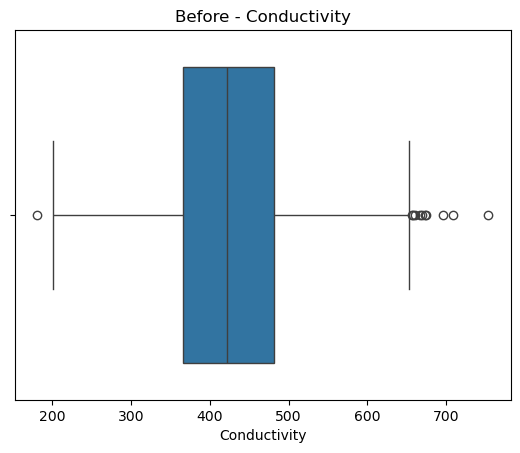

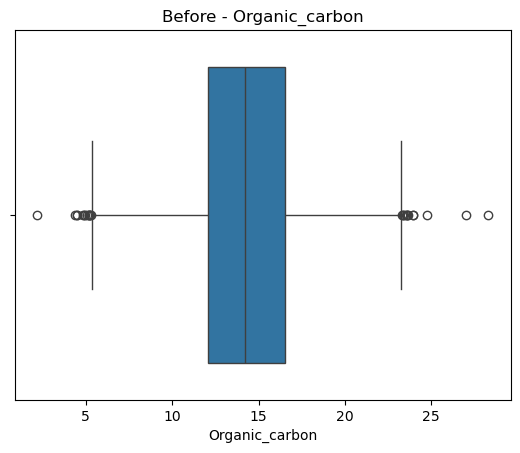

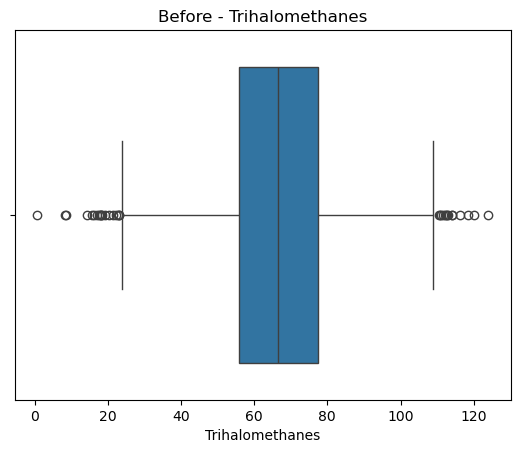

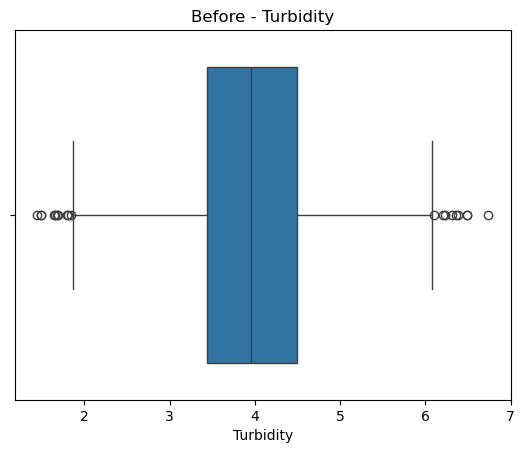

In [11]:
for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Before - {col}")
    plt.show()

In [12]:
df_clean = df.copy()

print("Filling Missing Values...")

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        
        if abs(df_clean[col].skew()) > 0.5:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

df_clean.isnull().sum()

Filling Missing Values...


ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [13]:
for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[col] = np.clip(df_clean[col], lower, upper)

In [15]:
# Medians
turb = df_clean['Turbidity'].median()
sol = df_clean['Solids'].median()
cond = df_clean['Conductivity'].median()
org = df_clean['Organic_carbon'].median()

def classify(row):
    score = 0
    
    if row["Turbidity"] > turb: score += 1
    if row["Solids"] > sol: score += 1
    if row["Conductivity"] > cond: score += 1
    if row["Organic_carbon"] > org: score += 1

    if score <= 1:
        return "LOW"
    elif score == 2:
        return "MEDIUM"
    else:
        return "HIGH"

df_clean["Microplastic_Level"] = df_clean.apply(classify, axis=1)

# Drop old target
df_clean = df_clean.drop(columns=["Potability"])

df_clean["Microplastic_Level"].value_counts()

Microplastic_Level
MEDIUM    1222
LOW       1048
HIGH      1006
Name: count, dtype: int64

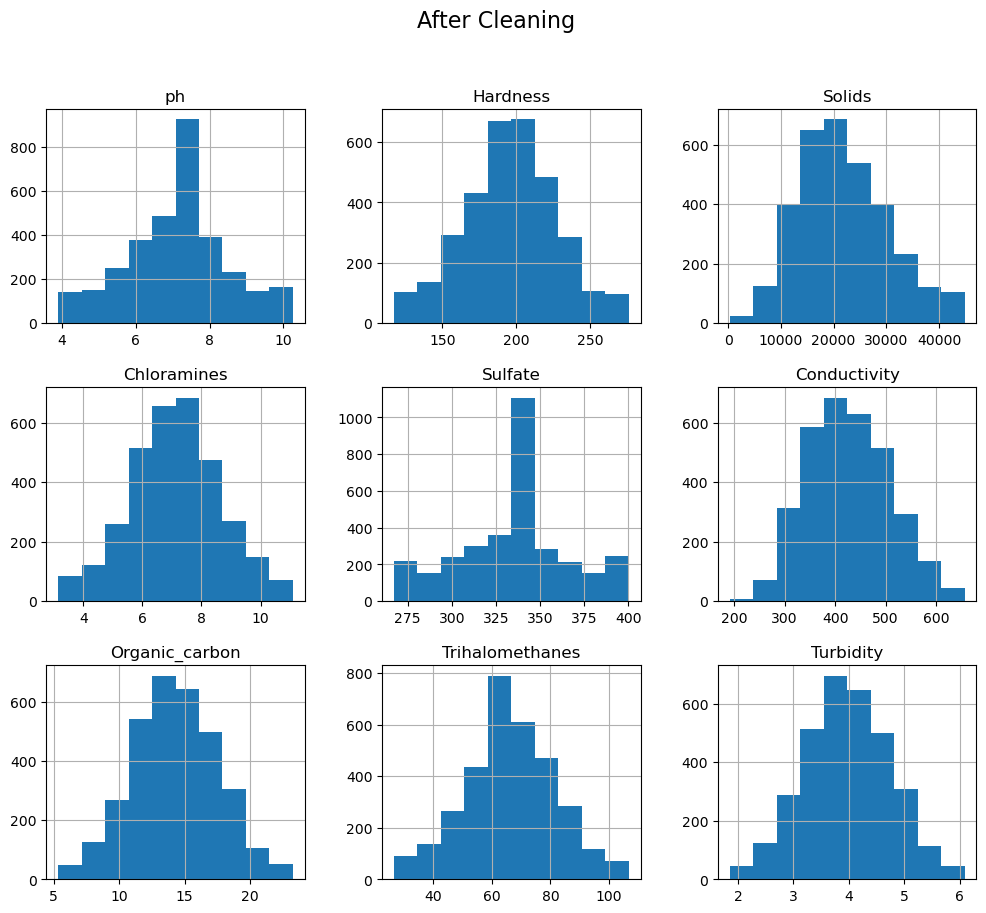

In [16]:
df_clean.hist(figsize=(12,10))
plt.suptitle("After Cleaning", fontsize=16)
plt.show()

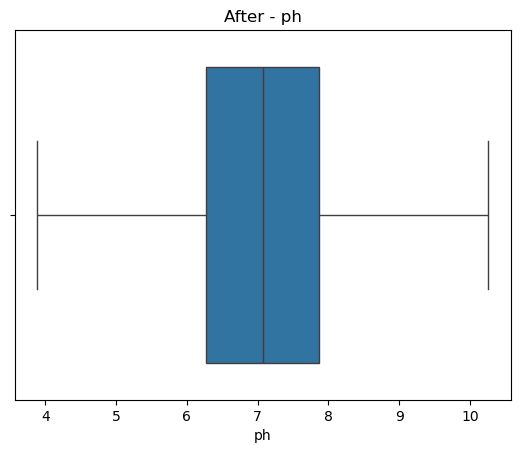

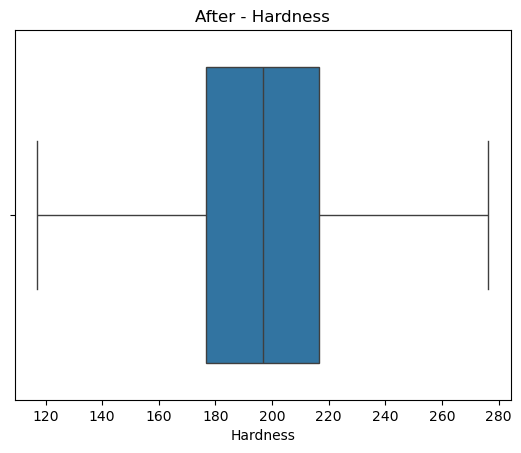

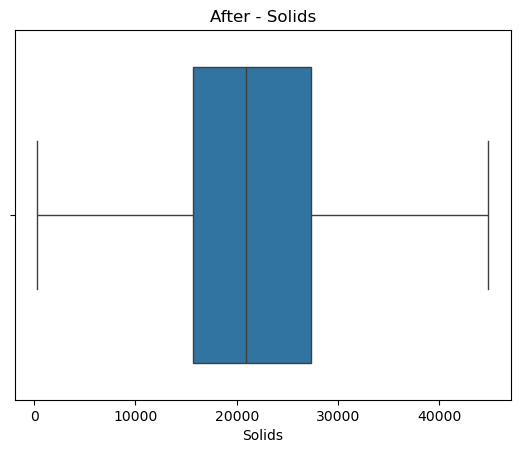

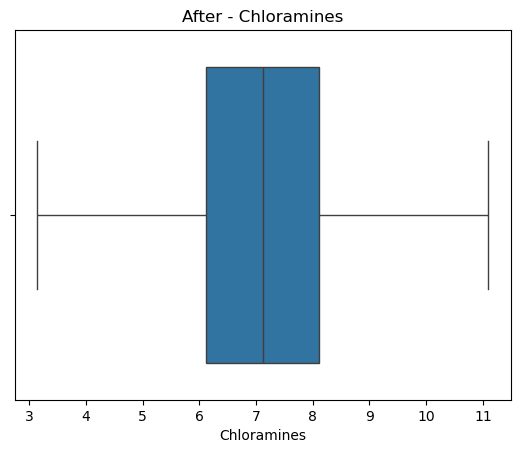

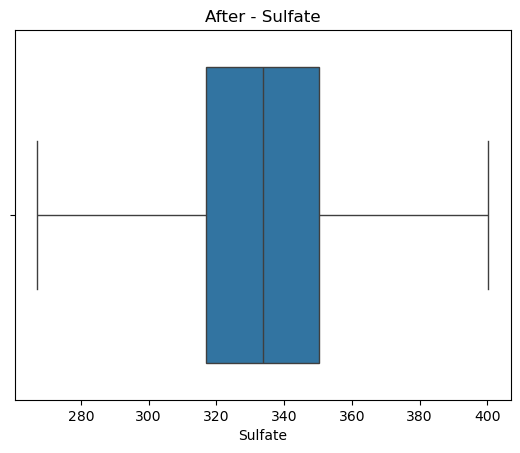

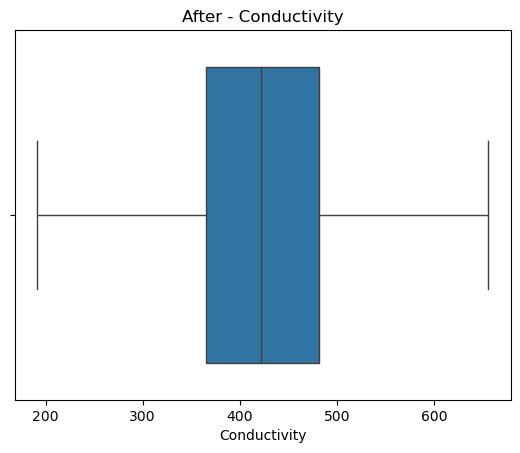

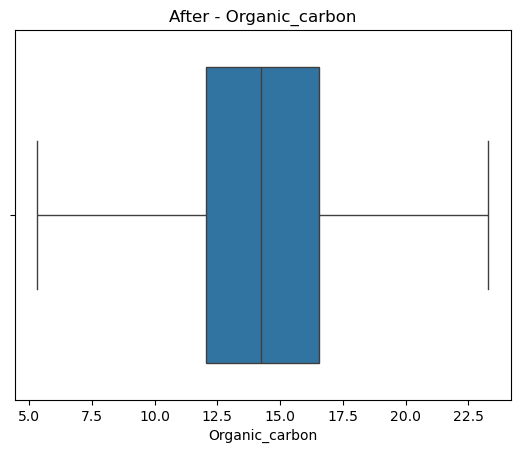

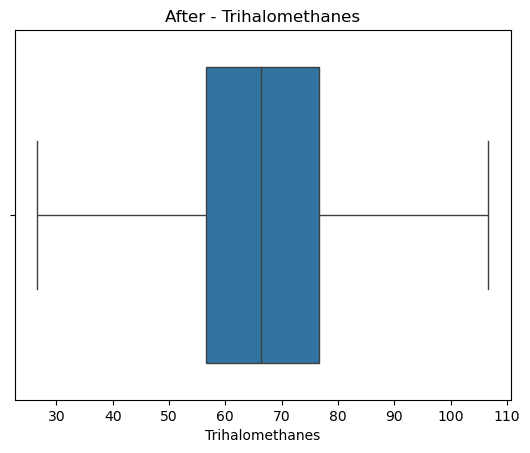

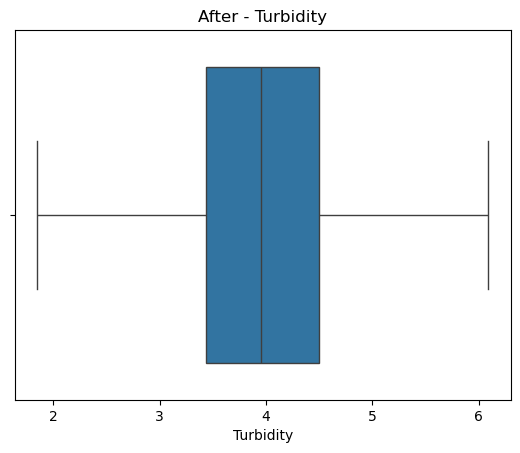

In [17]:
for col in cols:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(f"After - {col}")
    plt.show()

In [18]:
df_clean.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.079949,196.392423,21957.112200,7.121794,333.788678,426.129974,14.283462,66.420427,3.966612
std,1.381951,32.017189,8592.820397,1.544126,31.768004,80.564144,3.288367,15.487146,0.776409
min,3.889107,117.125160,320.942611,3.146221,267.157960,191.647579,5.328026,26.619225,1.848797
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711
50%,7.080795,196.967627,20927.833607,7.130299,333.775777,421.884968,14.218338,66.396293,3.955028
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320
max,10.258615,276.392834,44831.869873,11.096086,400.322434,655.879140,23.295427,106.695040,6.091233


In [19]:
df_clean.to_csv("final_data.csv", index=False)
print("Saved ✅")

Saved ✅


In [20]:
X = df_clean.drop("Microplastic_Level", axis=1)
y = df_clean["Microplastic_Level"]

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [21]:
# ============================================================
# ERROR METRICS (ACCURACY, PRECISION, RECALL, F1)
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predictions
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)

# Precision (macro = average across all classes)
precision = precision_score(y_test, y_pred, average='macro')

# Recall
recall = recall_score(y_test, y_pred, average='macro')

# F1 Score
f1 = f1_score(y_test, y_pred, average='macro')

print("===== MODEL PERFORMANCE =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

===== MODEL PERFORMANCE =====
Accuracy : 0.6585
Precision: 0.6583
Recall   : 0.6710
F1 Score : 0.6619


In [22]:
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.67      0.75      0.71       209
           1       0.70      0.75      0.73       195
           2       0.61      0.51      0.55       252

    accuracy                           0.66       656
   macro avg       0.66      0.67      0.66       656
weighted avg       0.65      0.66      0.65       656



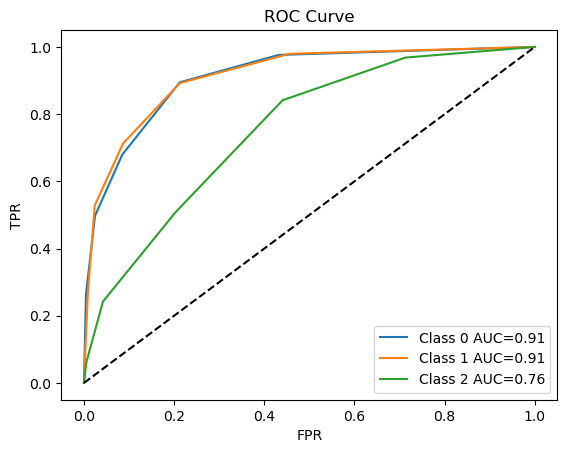

In [24]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = model.predict_proba(X_test)

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} AUC={roc_auc:.2f}')

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

In [25]:
with open("knn_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model Saved ✅")

Model Saved ✅
